# Chapter 11 - Novelty and Outlier Detection
## Detecting Anomalies with Isolation Forest and LOF
Based on scikit-learn Cookbook.

## Objective
Understand how anomaly detection identifies unusual observations that differ from normal patterns.

## Theory Introduction
Outliers are rare observations that differ significantly from the majority of data. They may indicate fraud, defects, sensor errors, or rare events.

Isolation Forest isolates anomalies using random splits, while Local Outlier Factor compares local density differences.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs
from sklearn.ensemble import IsolationForest
from sklearn.neighbors import LocalOutlierFactor
from sklearn.preprocessing import StandardScaler
plt.style.use('ggplot')

In [2]:
X,_ = make_blobs(n_samples=450, centers=2, cluster_std=1.2, random_state=42)
np.random.seed(42)
outliers = np.random.uniform(low=-8, high=8, size=(30,2))
X = np.vstack([X,outliers])
X = StandardScaler().fit_transform(X)
X.shape

(480, 2)

## Raw Data

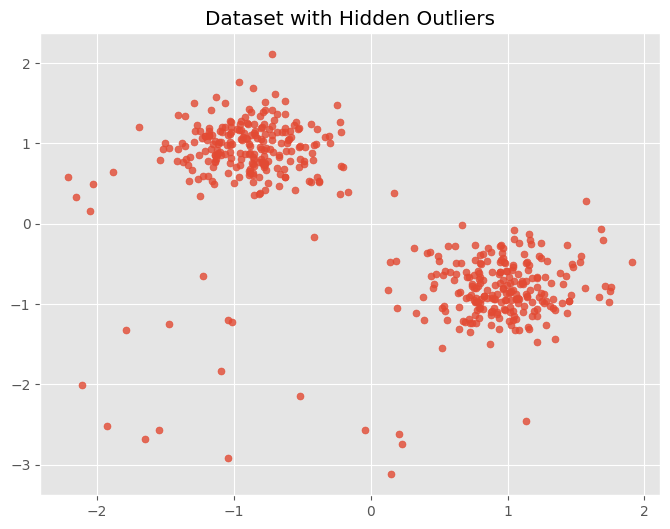

In [3]:
plt.figure(figsize=(8,6))
plt.scatter(X[:,0], X[:,1], s=25, alpha=0.8)
plt.title('Dataset with Hidden Outliers')
plt.show()

**Description:** Most points form dense groups, while a few isolated points may be anomalies.

## Isolation Forest

In [4]:
iso = IsolationForest(contamination=0.06, random_state=42)
labels_iso = iso.fit_predict(X)
scores = -iso.score_samples(X)

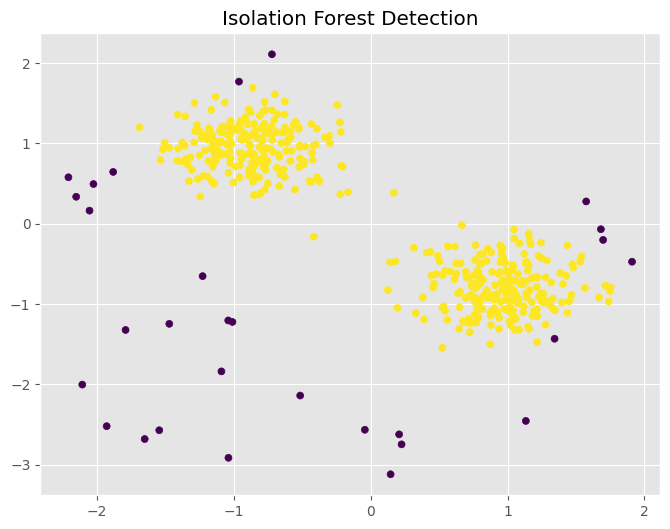

In [5]:
plt.figure(figsize=(8,6))
plt.scatter(X[:,0], X[:,1], c=labels_iso, s=25)
plt.title('Isolation Forest Detection')
plt.show()

**Description:** Predicted anomalies are separated from normal observations.

## Anomaly Score Distribution

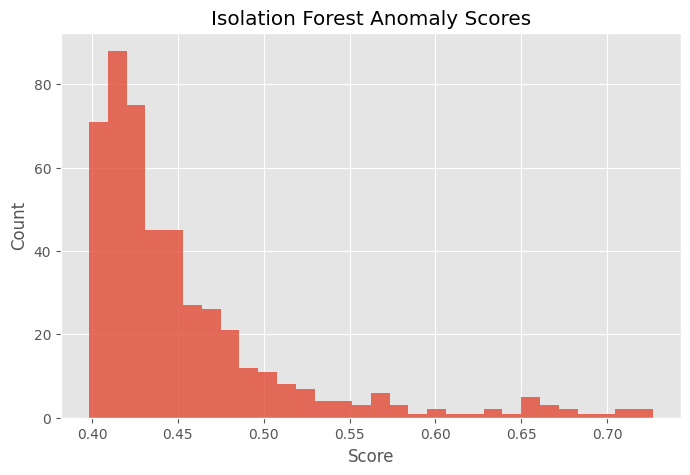

In [6]:
plt.figure(figsize=(8,5))
plt.hist(scores, bins=30, alpha=0.8)
plt.title('Isolation Forest Anomaly Scores')
plt.xlabel('Score')
plt.ylabel('Count')
plt.show()

**Description:** Higher anomaly scores generally indicate more unusual samples.

## Local Outlier Factor

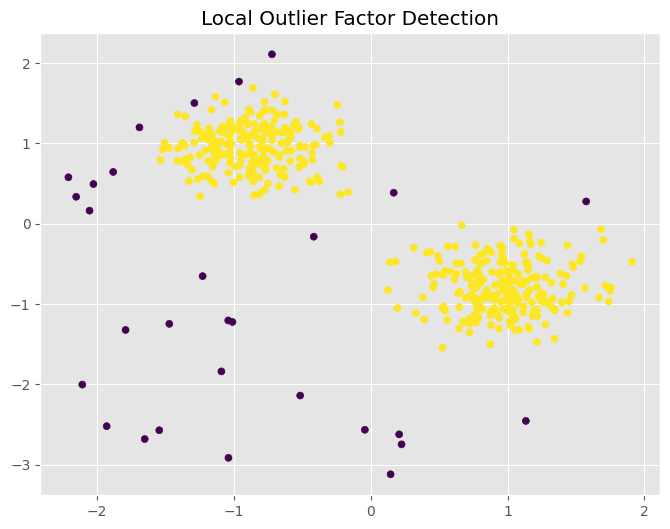

In [7]:
lof = LocalOutlierFactor(n_neighbors=20, contamination=0.06)
labels_lof = lof.fit_predict(X)
plt.figure(figsize=(8,6))
plt.scatter(X[:,0], X[:,1], c=labels_lof, s=25)
plt.title('Local Outlier Factor Detection')
plt.show()

**Description:** LOF flags points with much lower local density than their neighbors.

## Important Theory Concepts
- Outlier vs novelty detection
- Contamination parameter
- Isolation via random partitioning
- Density-based anomaly detection
- Real-world uses: fraud, defects, intrusion detection

## Summary
Anomaly detection helps identify rare and suspicious observations. Isolation Forest is scalable, while LOF is effective for local density patterns.